# Volatility and Business News

Companion to the **Applications: Nowcasting** slides. Those slides show Bybee, Kelly, Manela
and Xiu (2024) nowcasting industrial production and employment growth from 180 news-attention
series. We put the CBOE VIX on the left-hand side instead:

$$\log \mathrm{VIX}_t = \beta_0 + \sum_{j=1}^{180}\beta_j\,\theta_{j,t} + \varepsilon_t ,$$

where $\theta_{j,t}$ is the share of business-news attention devoted to topic $j$ in month $t$.
There are **180 predictors and 402 months**.

Two exercises: a **nowcast** (Section 2) of this month's volatility, and a **forecast**
(Section 3) of next month's.

**After this notebook you should be able to:**

1. use the lasso as a selection device;
2. explain why a sparse model can beat a far better-fitting one out of sample.

## 1. Setup and data

**The VIX** comes from FRED-MD as `VIXCLSx`, back-filled before 1990 with its VXO predecessor.

**The news topics** come from `Monthly_Topic_Attention_Theta.csv`, the topic model of Bybee et
al. (2024): a latent Dirichlet allocation fitted to the full text of the *Wall Street Journal*,
1984--2017. Each entry is a share of that month's attention, so the 180 shares sum to one.

In [1]:
import ssl
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

# FRED serves the file over a TLS chain that some Python builds reject
ssl._create_default_https_context = ssl._create_stdlib_context

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 710
N_TOPICS_WANTED = 5                            # how many topics the lasso may keep

TRAIN_END = pd.Period("2001-12", freq="M")     # last month used to estimate
VALID_END = pd.Period("2009-12", freq="M")     # last month used to pick the penalty

FRED_MD = ("https://www.stlouisfed.org/-/media/project/frbstl/stlouisfed/research/"
           "fred-md/monthly/2025-07-md.csv?sc_lang=en&hash=A1E7A098FEFE58C453870371DB34E6AF")

BLUE, GREEN, GOLD, RED = "#003865", "#64A70B", "#F2A900", "#DA291C"

In [2]:
def load_fred_md(path):
    """Load FRED-MD. The first row holds transformation codes; the last three are footnotes."""
    print("Be patient: loading FRED-MD from the St. Louis Fed")
    raw = pd.read_csv(path)[:-3]

    codes = raw.iloc[0, 1:].astype(int)
    raw = raw.drop(index=0).set_index("sasdate")
    raw.index = pd.to_datetime(raw.index, format="%m/%d/%Y").to_period("M")
    raw.index.name = "month"

    print("Done")
    return raw.astype(float), codes


fred, transformation_codes = load_fred_md(FRED_MD)
vix = fred["VIXCLSx"].dropna().rename("vix")

topics = pd.read_csv(Path("Monthly_Topic_Attention_Theta.csv"), parse_dates=["date"])
topics["month"] = topics["date"].dt.to_period("M")
topics = topics.drop(columns="date").set_index("month").sort_index()
TOPIC_NAMES = topics.columns.tolist()
k = len(TOPIC_NAMES)

data = topics.join(vix, how="inner").dropna()
data["log_vix"] = np.log(data["vix"])
n = len(data)

print(f"\nVIXCLSx : transformation code {transformation_codes['VIXCLSx']} (a level), "
      f"{len(vix)} months")
print(f"Topics  : {len(topics)} months, {k} series")
print(f"Merged  : {n} months ({data.index.min()} to {data.index.max()})")
print(f"n / k   : {n / k:.2f} observations per coefficient")
print(f"Shares  : sum to {data[TOPIC_NAMES].sum(axis=1).min():.4f} every month")
data[["Recession", "Financial crisis", "Options/VIX", "vix", "log_vix"]].head(3)

Be patient: loading FRED-MD from the St. Louis Fed


Done

VIXCLSx : transformation code 1 (a level), 753 months
Topics  : 402 months, 180 series
Merged  : 402 months (1984-01 to 2017-06)
n / k   : 2.23 observations per coefficient
Shares  : sum to 1.0000 every month


,Recession,Financial crisis,Options/VIX,vix,log_vix
month,,,,,
1984-01,0.0034,0.0028,0.0053,16.2294,2.7868
1984-02,0.0038,0.0031,0.0059,22.0363,3.0927
1984-03,0.0030,0.0026,0.0058,18.9248,2.9405


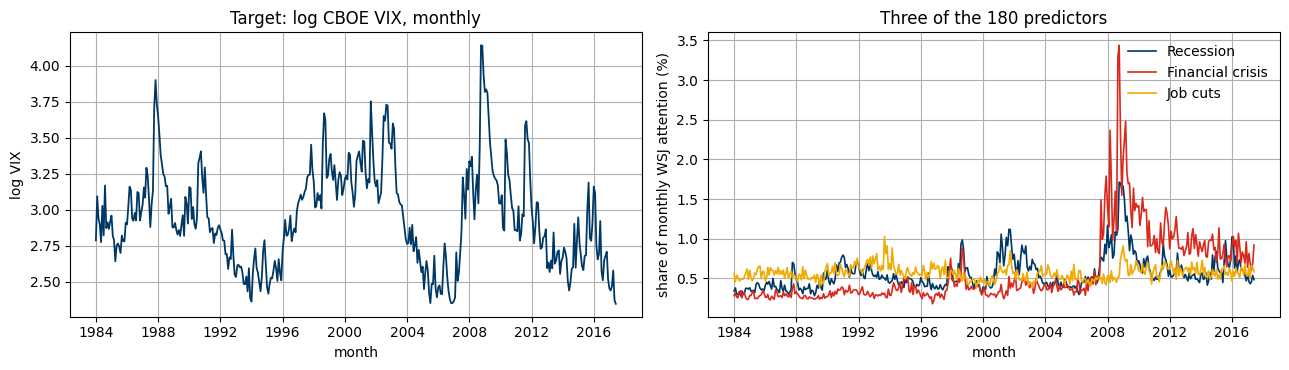

In [3]:
month_index = data.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(month_index, data["log_vix"], color=BLUE, lw=1.3)
axes[0].set_ylabel("log VIX")
axes[0].set_xlabel("month")
axes[0].set_title("Target: log CBOE VIX, monthly")

for name, colour in [("Recession", BLUE), ("Financial crisis", RED), ("Job cuts", GOLD)]:
    axes[1].plot(month_index, 100 * data[name], lw=1.2, color=colour, label=name)
axes[1].set_ylabel("share of monthly WSJ attention (%)")
axes[1].set_xlabel("month")
axes[1].set_title(f"Three of the {k} predictors")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 2. Nowcasting: five topics that explain the VIX

Bybee et al. report *which* topics carry the signal, not just how well the model fits. This
section uses the **whole sample**, because the question is descriptive not predictive. 

The topics are standardized first: the $\ell_1$ penalty applies to raw coefficients, so without
standardization the selection would reflect units rather than volatility. Then, rather than fix
a penalty and see what emerges, we walk the penalty *down* until the fifth topic enters --- so
the number of topics is the choice and the penalty its consequence.

The comparison is OLS on all 180. Both see identical data.

In [4]:
X_full = (data[TOPIC_NAMES] - data[TOPIC_NAMES].mean()) / data[TOPIC_NAMES].std(ddof=0)
y_full = data["log_vix"]

for penalty in np.logspace(0, -4, 600):
    lasso_nowcast = Lasso(alpha=penalty, max_iter=200_000, random_state=SEED).fit(X_full, y_full)
    if (lasso_nowcast.coef_ != 0).sum() >= N_TOPICS_WANTED:
        break

ols_nowcast = LinearRegression().fit(X_full, y_full)

lasso_coefficients = pd.Series(lasso_nowcast.coef_, index=TOPIC_NAMES)
ols_coefficients = pd.Series(ols_nowcast.coef_, index=TOPIC_NAMES)
selected = lasso_coefficients[lasso_coefficients != 0].sort_values()

print(f"Lasso penalty at which {len(selected)} topics have entered: {penalty:.4f}\n")

pd.DataFrame([
    {"model": f"lasso, {len(selected)} topics", "R-squared": lasso_nowcast.score(X_full, y_full),
     "coefficients used": len(selected), "sum |coefficients|": lasso_coefficients.abs().sum()},
    {"model": f"OLS, all {k} topics", "R-squared": ols_nowcast.score(X_full, y_full),
     "coefficients used": k, "sum |coefficients|": ols_coefficients.abs().sum()},
]).set_index("model").round(4)

Lasso penalty at which 5 topics have entered: 0.0895



,R-squared,coefficients used,sum |coefficients|
model,,,
"lasso, 5 topics",0.3937,5,0.1644
"OLS, all 180 topics",0.9188,180,3.6587


On this
evidence OLS is the better model. The $\ell_1$ penalty is a constraint on $\sum_j|\beta_j|$.

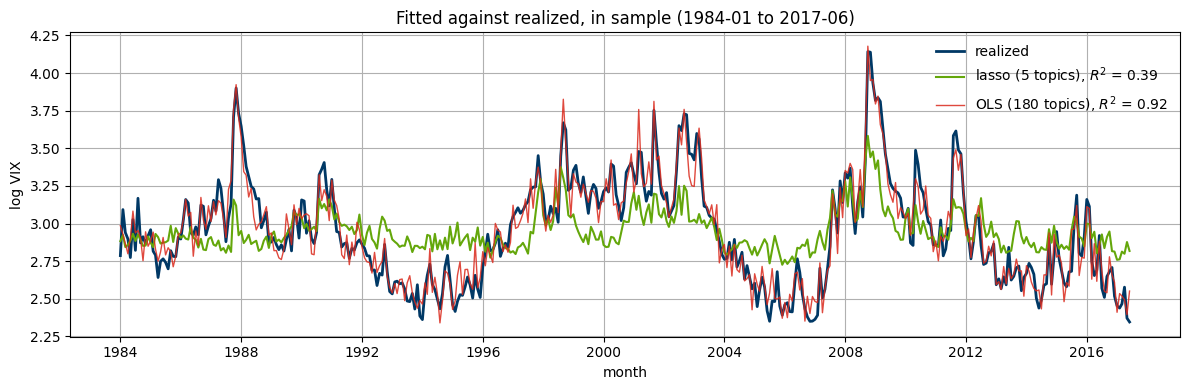

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(month_index, y_full, color=BLUE, lw=2, label="realized")
ax.plot(month_index, lasso_nowcast.predict(X_full), color=GREEN, lw=1.5,
        label=f"lasso ({len(selected)} topics), $R^2$ = {lasso_nowcast.score(X_full, y_full):.2f}")
ax.plot(month_index, ols_nowcast.predict(X_full), color=RED, lw=1.0, alpha=0.85,
        label=f"OLS ({k} topics), $R^2$ = {ols_nowcast.score(X_full, y_full):.2f}")
ax.set_ylabel("log VIX")
ax.set_xlabel("month")
ax.set_title(f"Fitted against realized, in sample ({data.index.min()} to {data.index.max()})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

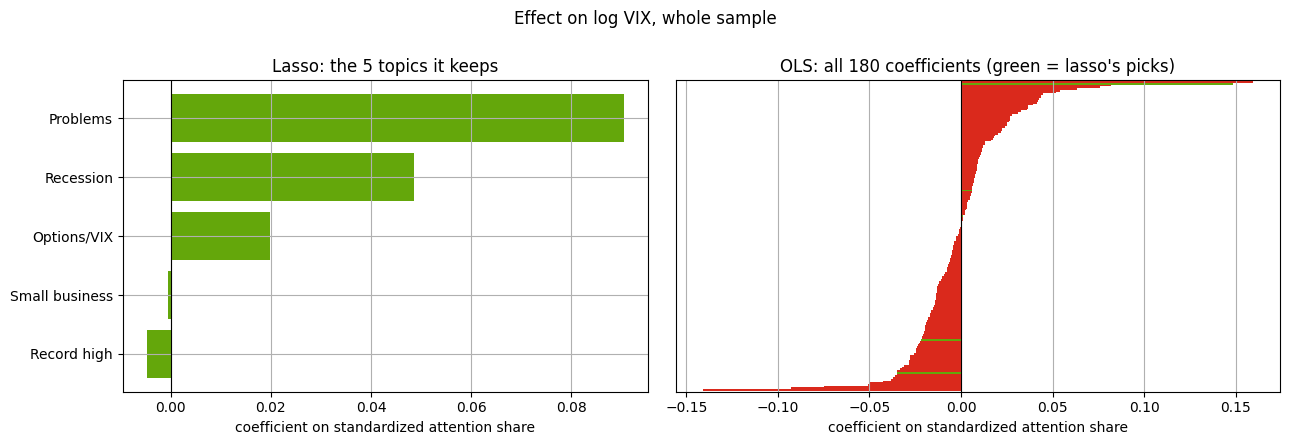

The 5 largest |coefficients| OLS chose instead:
Exchanges/composites          0.1592
Recession                     0.1486
Corrections/amplifications   -0.1406
Trading activity             -0.0931
People familiar               0.0821


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1, 1.15]})

axes[0].barh(range(len(selected)), selected.to_numpy(), color=GREEN)
axes[0].set_yticks(range(len(selected)))
axes[0].set_yticklabels(selected.index)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("coefficient on standardized attention share")
axes[0].set_title(f"Lasso: the {len(selected)} topics it keeps")

ols_sorted = ols_coefficients.sort_values()
axes[1].barh(range(k), ols_sorted.to_numpy(), height=1.0,
             color=[GREEN if name in selected.index else RED for name in ols_sorted.index])
axes[1].set_yticks([])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_ylim(-1, k)
axes[1].set_xlabel("coefficient on standardized attention share")
axes[1].set_title(f"OLS: all {k} coefficients (green = lasso's picks)")

fig.suptitle("Effect on log VIX, whole sample", y=1.0)
plt.tight_layout()
plt.show()

print(f"The {N_TOPICS_WANTED} largest |coefficients| OLS chose instead:")
print(ols_coefficients[ols_coefficients.abs().nlargest(N_TOPICS_WANTED).index].round(4).to_string())

The green bars are scattered through the OLS ranking rather than sitting at its extremes: only
"Recession" appears in both top-five lists. 

The lasso's five coefficients are interpretable.

## 3. Forecasting: which topics predict next month?

The predictors are now lagged one month and the sample is cut three ways.

**Select (3.1).** Estimate on **train**, choose the penalty on **validation**. Standardization
uses training-block moments only; full-sample moments would leak the validation and test months
into the training data.

**Estimate (3.2).** Models whose settings do *not* come from validation error are re-estimated
on **train + validation**.

The **test** block is used once, in 3.3.

In [7]:
lagged = pd.concat([data[TOPIC_NAMES].shift(1), data[["log_vix"]]], axis=1).dropna()

train = lagged.loc[:TRAIN_END]
valid = lagged.loc[(lagged.index > TRAIN_END) & (lagged.index <= VALID_END)]
test = lagged.loc[lagged.index > VALID_END]


def standardize(block, fitted_on):
    """Standardize `block` using the mean and standard deviation of `fitted_on`."""
    moments = fitted_on[TOPIC_NAMES]
    return (block[TOPIC_NAMES] - moments.mean()) / moments.std(ddof=0)


X_train, y_train = standardize(train, fitted_on=train), train["log_vix"]
X_valid, y_valid = standardize(valid, fitted_on=train), valid["log_vix"]
y_test = test["log_vix"]

for name, block in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:<11}: {block.index.min()} to {block.index.max()}  {len(block):>3} months  "
          f"mean VIX {np.exp(block['log_vix'].mean()):>4.1f}  "
          f"peak VIX {np.exp(block['log_vix'].max()):>4.0f}")

train      : 1984-02 to 2001-12  215 months  mean VIX 19.7  peak VIX   49
validation : 2002-01 to 2009-12   96 months  mean VIX 19.9  peak VIX   63
test       : 2010-01 to 2017-06   90 months  mean VIX 16.8  peak VIX   37


The blocks are not alike. Validation contains the 2008 crisis and the sample's highest VIX;
test is the calmest of the three. A penalty tuned on a crisis and applied to a calm decade is a realistic difficulty.

### 3.1 Selecting the topics

The figure traces validation error against the number of topics kept, and marks two choices:
the five-topic model, and the penalty that simply minimizes validation MSE.

five topics      : penalty 0.1081,   5 topics, validation MSE 0.2245
lowest validation: penalty 0.0036,  81 topics, validation MSE 0.2020
no topics at all : validation MSE 0.2033  <- the training mean, no news


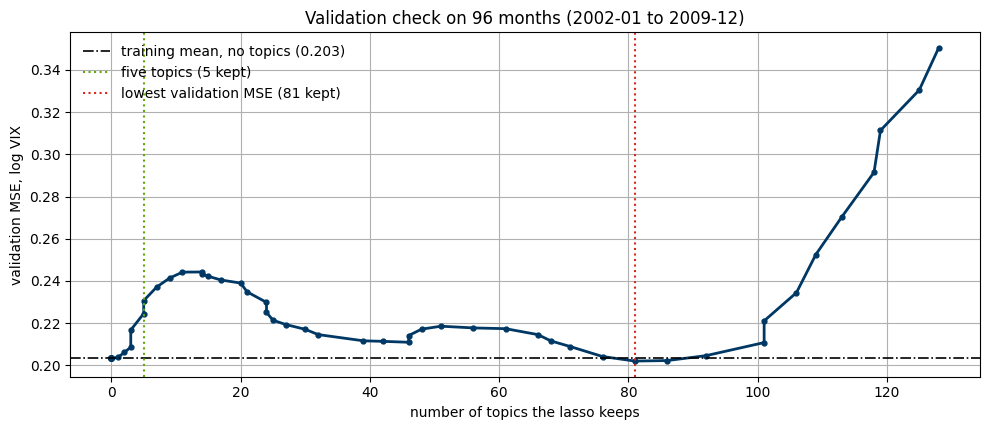

In [8]:
penalty_grid = np.logspace(0, -3, 60)

validation_mse, topics_kept = [], []
for candidate in penalty_grid:
    model = Lasso(alpha=candidate, max_iter=200_000, random_state=SEED).fit(X_train, y_train)
    validation_mse.append(mean_squared_error(y_valid, model.predict(X_valid)))
    topics_kept.append((model.coef_ != 0).sum())

validation_mse, topics_kept = np.array(validation_mse), np.array(topics_kept)

five_topic_index = int(np.where(topics_kept >= N_TOPICS_WANTED)[0].min())
lowest_mse_index = int(validation_mse.argmin())
lowest_mse_penalty = penalty_grid[lowest_mse_index]

# Where the penalty is so large nothing enters, the lasso is just the training mean
null_model_mse = validation_mse[topics_kept == 0].max()

print(f"five topics      : penalty {penalty_grid[five_topic_index]:.4f}, "
      f"{topics_kept[five_topic_index]:>3} topics, validation MSE "
      f"{validation_mse[five_topic_index]:.4f}")
print(f"lowest validation: penalty {lowest_mse_penalty:.4f}, "
      f"{topics_kept[lowest_mse_index]:>3} topics, validation MSE "
      f"{validation_mse[lowest_mse_index]:.4f}")
print(f"no topics at all : validation MSE {null_model_mse:.4f}  <- the training mean, no news")

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(topics_kept, validation_mse, color=BLUE, lw=2, marker="o", ms=3.5)
ax.axhline(null_model_mse, color="black", lw=1.2, ls="-.",
           label=f"training mean, no topics ({null_model_mse:.3f})")
ax.axvline(topics_kept[five_topic_index], color=GREEN, lw=1.5, ls=":",
           label=f"five topics ({topics_kept[five_topic_index]} kept)")
ax.axvline(topics_kept[lowest_mse_index], color=RED, lw=1.5, ls=":",
           label=f"lowest validation MSE ({topics_kept[lowest_mse_index]} kept)")
ax.set_xlabel("number of topics the lasso keeps")
ax.set_ylabel("validation MSE, log VIX")
ax.set_title(f"Validation check on {len(valid)} months "
             f"({valid.index.min()} to {valid.index.max()})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The minimum sits at 81 topics and beats the five-topic model by about 10% of MSE. 

The dash-dotted line: a lasso penalized so that it keeps *nothing* --- a forecast that is just
the training mean.

### 3.2 Estimating the final models

The five-topic lasso and OLS are re-estimated on train + validation: neither takes a hyperparameter estimated
from validation error.

The five-topic rule is re-applied rather than the penalty reused, because `scikit-learn` scales
the lasso objective by $1/(2n)$: the same `alpha` shrinks by a different amount on a larger
sample.

lasso, five topics     : 311 months, penalty 0.1144, 5 topics
OLS                    : 311 months, 180 topics, training R-squared 0.9295
lasso, lowest-MSE rule : 215 months (train only), penalty 0.0036, 81 topics

Chosen by both nowcast and forecast: Problems, Recession, Small business


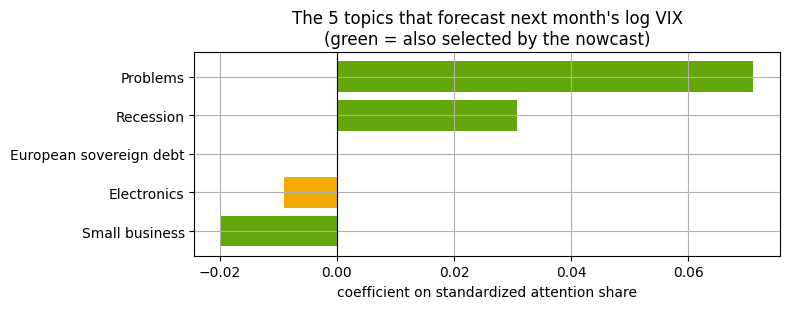

In [9]:
fit_block = lagged.loc[:VALID_END]                    # train + validation
X_fit, y_fit = standardize(fit_block, fitted_on=fit_block), fit_block["log_vix"]

# Each model carries the standardization of the block it was estimated on
X_test_fit = standardize(test, fitted_on=fit_block)
X_test_train = standardize(test, fitted_on=train)

for forecast_penalty in np.logspace(0, -4, 600):
    forecast_model = Lasso(alpha=forecast_penalty, max_iter=200_000, random_state=SEED)
    forecast_model.fit(X_fit, y_fit)
    if (forecast_model.coef_ != 0).sum() >= N_TOPICS_WANTED:
        break

ols_forecast_model = LinearRegression().fit(X_fit, y_fit)
lowest_mse_model = Lasso(alpha=lowest_mse_penalty, max_iter=200_000,
                         random_state=SEED).fit(X_train, y_train)

forecast_coefficients = pd.Series(forecast_model.coef_, index=TOPIC_NAMES)
forecast_topics = forecast_coefficients[forecast_coefficients != 0].sort_values()

print(f"lasso, five topics     : {len(fit_block)} months, penalty {forecast_penalty:.4f}, "
      f"{len(forecast_topics)} topics")
print(f"OLS                    : {len(fit_block)} months, {k} topics, "
      f"training R-squared {ols_forecast_model.score(X_fit, y_fit):.4f}")
print(f"lasso, lowest-MSE rule : {len(train)} months (train only), "
      f"penalty {lowest_mse_penalty:.4f}, {(lowest_mse_model.coef_ != 0).sum()} topics")
print(f"\nChosen by both nowcast and forecast: "
      f"{', '.join(sorted(set(forecast_topics.index) & set(selected.index)))}")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(range(len(forecast_topics)), forecast_topics.to_numpy(),
        color=[GREEN if name in selected.index else GOLD for name in forecast_topics.index])
ax.set_yticks(range(len(forecast_topics)))
ax.set_yticklabels(forecast_topics.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coefficient on standardized attention share")
ax.set_title(f"The {len(forecast_topics)} topics that forecast next month's log VIX\n"
             f"(green = also selected by the nowcast)")
plt.tight_layout()
plt.show()

### 3.3 Out-of-sample test

$R^2$ is measured against the mean log VIX over the estimation months. It is $0$ for a model matching
that flat forecast and **negative** for one that does worse, meaning it would have been beaten
by someone who ignored the news and quoted a long-run average.

In [10]:
def evaluate(predicted, label):
    """MSE, MAE, and out-of-sample R-squared against the pre-test mean log VIX."""
    actual = y_test.to_numpy()
    model_mse = mean_squared_error(actual, np.asarray(predicted, dtype=float))
    flat_mse = mean_squared_error(actual, np.full(len(actual), y_fit.mean()))

    return {"model": label, "MSE": model_mse,
            "MAE": mean_absolute_error(actual, np.asarray(predicted, dtype=float)),
            "R2 vs pre-test mean": 1 - model_mse / flat_mse}


sparse_label = f"lasso, {len(forecast_topics)} topics"
dense_label = f"lasso, lowest validation MSE ({(lowest_mse_model.coef_ != 0).sum()} topics)"
ols_label = f"OLS, all {k} topics"

results = pd.DataFrame([
    evaluate(forecast_model.predict(X_test_fit), sparse_label),
    evaluate(lowest_mse_model.predict(X_test_train), dense_label),
    evaluate(ols_forecast_model.predict(X_test_fit), ols_label),
]).set_index("model")

print(f"Test months: {test.index.min()} to {test.index.max()} ({len(test)} months)\n")
results.round(4)

Test months: 2010-01 to 2017-06 (90 months)



,MSE,MAE,R2 vs pre-test mean
model,,,
"lasso, 5 topics",0.0864,0.2544,0.1420
"lasso, lowest validation MSE (81 topics)",0.1593,0.3604,-0.5823
"OLS, all 180 topics",0.2259,0.4084,-1.2445


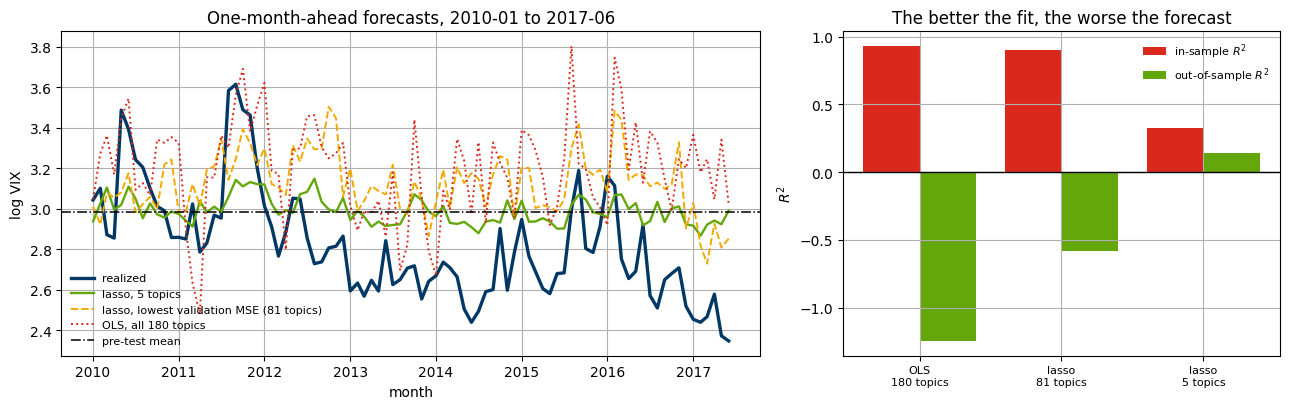

In [11]:
test_months = test.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})

axes[0].plot(test_months, y_test, color=BLUE, lw=2.4, label="realized")
axes[0].plot(test_months, forecast_model.predict(X_test_fit), color=GREEN, lw=1.7,
             label=sparse_label)
axes[0].plot(test_months, lowest_mse_model.predict(X_test_train), color=GOLD, lw=1.4, ls="--",
             label=dense_label)
axes[0].plot(test_months, ols_forecast_model.predict(X_test_fit), color=RED, lw=1.4, ls=":",
             label=ols_label)
axes[0].axhline(y_fit.mean(), color="black", lw=1.1, ls="-.", label="pre-test mean")
axes[0].set_ylabel("log VIX")
axes[0].set_xlabel("month")
axes[0].set_title(f"One-month-ahead forecasts, {test.index.min()} to {test.index.max()}")
axes[0].legend(frameon=False, fontsize=8)

in_sample = [ols_forecast_model.score(X_fit, y_fit), lowest_mse_model.score(X_train, y_train),
             forecast_model.score(X_fit, y_fit)]
out_sample = [results.loc[label, "R2 vs pre-test mean"]
              for label in [ols_label, dense_label, sparse_label]]
labels = [f"OLS\n{k} topics", f"lasso\n{(lowest_mse_model.coef_ != 0).sum()} topics",
          f"lasso\n{len(forecast_topics)} topics"]

x = np.arange(3)
axes[1].bar(x - 0.2, in_sample, width=0.4, color=RED, label="in-sample $R^2$")
axes[1].bar(x + 0.2, out_sample, width=0.4, color=GREEN, label="out-of-sample $R^2$")
axes[1].axhline(0, color="black", lw=1.0)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel("$R^2$")
axes[1].set_title("The better the fit, the worse the forecast")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

The right-hand panel identified the bias-variance tradeoff
**Extension questions**

1. **Is the five-topic list stable?** Re-run Section 2 on 1984--2000 and 2001--2017 separately.
2. **Does the news add anything to persistence?** Volatility is highly persistent, so the honest
   benchmark is last month's VIX, not the sample mean. Add `log_vix.shift(1)` to the predictors
   and re-score against an AR(1). 
3. **Move the split.** Set `TRAIN_END` to 2005-12 and `VALID_END` to 2011-12. How much do the selected topics and the ranking change, and what
   does that sensitivity say about trusting any single split?